In [1]:
%matplotlib inline
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
import scipy.io as sio
import matplotlib
import logging

# import utils as utils
from matplotlib import cm

In [2]:
runname = 'debug_withC_rogers_netcdfBdy1_EB_soliton_withsponge_focus_finey_summer'
datafilepath = '/Volumes/Tan_2024/SUNTANS/NLIW/iwave2024/dongsha/'+runname+'/data_nof_1wave/'

# datafilename = 'sun_out.nc_0000.nc'
datafilename = 'sun_sparse.nc_0000.nc'

# path to saved result
resultfilepath = datafilepath+'/results/'
# path to saved figures
outfilepath = '../figure/'
if not os.path.exists(resultfilepath):
    os.mkdir(resultfilepath)
if not os.path.exists(outfilepath):
    os.mkdir(outfilepath)

param_data = {
    "datafilepath": datafilepath,
    "netcdf_filename": datafilename,
            }
param_result = {
    "resultfilepath": resultfilepath,
    "result_filename": 'sun_out_energy_derived.nc',
            }
idx_end = -15

# Read data

In [3]:
data = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'][:-3]+'_dissp.nc')
data_ = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'])

In [4]:
# read data
Data = xr.open_dataset(datafilepath+datafilename)

# grid info
import mat73
grid = mat73.loadmat('/Volumes/Tan_2024/SUNTANS/NLIW/iwave2024/dongsha/'+runname+'/mfiles/SUNTANS_grid.mat', only_include=['Nk', 'Nx', 'Ny', 'Depth', 'INPUT']) 

Nx = grid['Nx'].astype('int')
Ny = grid['Ny'].astype('int')
Nk = grid['Nk'].astype('int')
Nc = Nx*Ny
# Depth = np.reshape(grid['Depth'].astype('int'), (Nx, Ny), order='F')
Depth = np.reshape(grid['Depth'], (Nx, Ny), order='F')

xv = np.reshape(Data.xv.data, (Nx, Ny), order='F')
yv = np.reshape(Data.yv.data, (Nx, Ny), order='F')

In [5]:
U = np.reshape(Data.Ubt.data, (len(Data.time), Nx, Ny), order='F')
V = np.reshape(Data.Vbt.data, (len(Data.time), Nx, Ny), order='F')

In [6]:
del Data

## Slope bathymetry & Shoaling depth

In [7]:
lambdaM2=70.1e3
l_sponge = 20e3
slope = 0.05
D0 = 600
L=1.5*lambdaM2+2*l_sponge
W=1.5*lambdaM2
He = 313.1
width_he2 = 26000
width_top = width_he2 - 2*(He/2)/slope

x_c = 2*l_sponge+1.5*lambdaM2/2 
y_c = W/2

In [8]:
depth_top = 4
depth_shoal = 180
depth_bottom = 600-1e-2

In [9]:
x_top = x_c+width_top/2
x_bottom = x_top + D0/slope
x_shoal = x_top + depth_shoal/slope

## scale time

In [10]:
dt = (data.time.data-data.time[0].data).astype('int')*1e-9
c = 1.715370234806147
L_w = 6.387548003396961e+03/2

T_scale = L_w*2/c
t_nondim = dt/T_scale

# evolution of U + $\eta$

In [11]:
data_Cadv = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'][:-3]+'_Cadv.nc')
Cadv = data_Cadv.Ah0.interp(time=data.time)

In [12]:
# eta_ = data_.eta[:,:,int(Ny/2)].copy()
# C_ = data_.C_int[:,:,int(Ny/2)].differentiate("time",datetime_unit="s") + Cadv
eta_ = data_.eta.copy()

In [13]:
# calculate dynamic height
data_f=xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'][:-3]+'_bt_flux_x.nc')
# Fx_03_ = data_f.Fx_03_int[:,:,int(Ny/2)].differentiate("time",datetime_unit="s")
Fx_03_ = data_f.Fx_03_int.differentiate("time",datetime_unit="s")
del data_f

rho0 = 1000
grav = 9.81
# p_prime_height_ = Fx_03_/U[:,:,int(Ny/2)]/rho0/grav/data_.depth[:,int(Ny/2)].data
p_prime_height_ = Fx_03_/U/rho0/grav/data_.depth.data

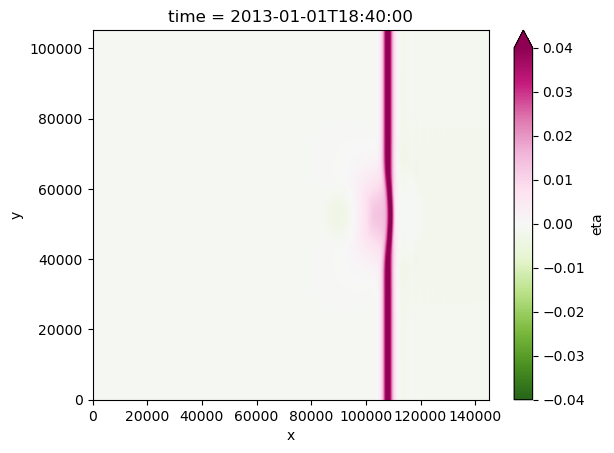

In [14]:
idx_t_data = 50
eta_[idx_t_data,:,:].T.plot(vmin=-4e-2, vmax=4e-2, cmap=cm.PiYG_r)

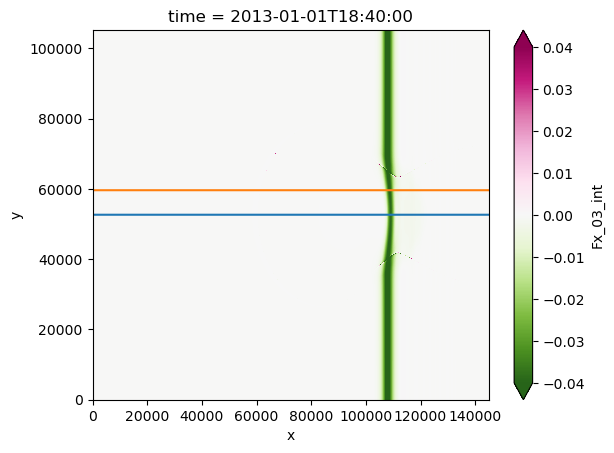

In [15]:
p_prime_height_[idx_t_data,:,:].T.plot(vmin=-4e-2, vmax=4e-2, cmap=cm.PiYG_r)
plt.plot(data.x.data, np.ones(data.x.shape)*data.y[int(Ny/2)].data)
plt.plot(data.x.data, np.ones(data.x.shape)*data.y[int(Ny/2)+125].data)

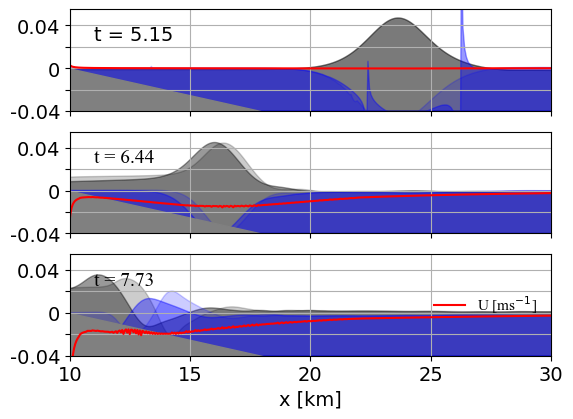

In [16]:
count = 0
fig, ax1 = plt.subplots(nrows=3, ncols=1, figsize=(6.2,1.5*3))
for idx_t_data in np.arange(40,60+1,10): 
    ax1[count].fill_between(data.x.data, eta_[idx_t_data,:,int(Ny/2)].data, -.04*np.ones(data.x.data.shape), color='k', alpha=.2)#, label=r'$\eta$ [m]')
    # ax1[count].plot(data.x.data, eta_[idx_t_data,:,int(Ny/2)+125].data, color='k')#, label=r'$\eta$ [m]')
    ax1[count].fill_between(data.x.data, eta_[idx_t_data,:,int(Ny/2)+125].data, -.04*np.ones(data.x.data.shape), color='k', alpha=.4)#, label=r'$\eta$ [m]')
    ax1[count].fill_between(data.x.data, p_prime_height_[idx_t_data,:,int(Ny/2)].data, -.04*np.ones(data.x.data.shape), color='b', alpha=.2)#, label=r'$\eta$ [m]')
    # ax1[count].plot(data.x.data, p_prime_height_[idx_t_data,:,int(Ny/2)+125].data, color='b')#, label=r'$\eta$ [m]')
    ax1[count].fill_between(data.x.data, p_prime_height_[idx_t_data,:,int(Ny/2)+125].data, -.04*np.ones(data.x.data.shape), color='b', alpha=.4)#, label=r'$\eta$ [m]')
    ax1[count].plot(data.x.data, U[idx_t_data,:,int(Ny/2)], c='r', linestyle='-', label=r'U [ms$^{-1}$]')
    # ax1[count].plot(data.x.data, V[idx_t_data,:,int(Ny/2)+5]*10, c='r', linestyle='--', label=r'10*V$_N$ [ms$^{-1}$]')
    # ax1[count].plot(data.x.data, V[idx_t_data,:,int(Ny/2)-5]*10, c='r', linestyle=':', label=r'10*V$_S$ [ms$^{-1}$]')
    ax1[count].set_xlim([x_c+10000,x_c+30000])
    ax1[count].set_xticks(np.arange(x_c+10000,x_c+30000+1,5000))
    ax1[count].set_ylim([-.04, .055])
    ax1[count].set_yticks(np.arange(-.04,.05,.02))      
    ax1[count].set_yticklabels(['-0.04', '', '0', '', '0.04'])
    if count == 2:
        ax1[count].set_xticklabels(['10', '15', '20', '25', '30'])
        ax1[count].legend(ncol=1, loc='right',frameon=False, fontsize=11)
        ax1[count].set_xlabel(r'x [km]', fontsize=14)
    else:
        ax1[count].set_xticklabels(['', '', '', '', ''])
    # ax1[count].set_title(r'$\eta$ [m] or U [ms$^{-1}$]', fontsize=14)
    ax1[count].grid(True)
    ax1[count].fill_between(data.x.data, -data_.depth[:,int(Ny/2)].data*1e-4, np.zeros(data.x.data.shape)-600*1e-4, color='.5')
    
    ax1[count].text(x_c+11000,.026, f"t = {np.round(t_nondim[idx_t_data],2)}", fontsize=14, color='k')
    ax1[count].set_ylabel('')
    ax1[count].tick_params(axis='both', which='major', labelsize=14)
    plt.rcParams["font.family"] = "Times New Roman"
    # fig.tight_layout()
    # plt.savefig(outfilepath+ f"U_eta_slice_summer_nof_3d_p_eta.png", transparent=True, dpi=300)

    count += 1

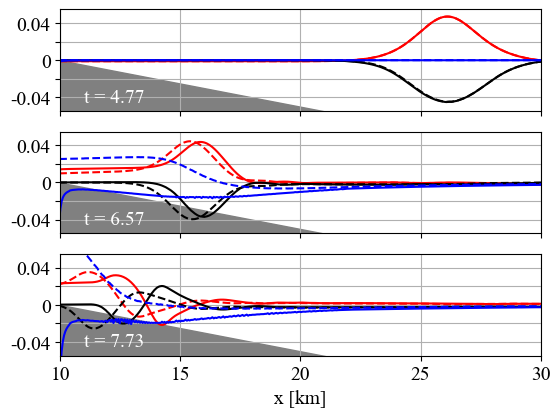

In [17]:
count = 0
fig, ax1 = plt.subplots(nrows=3, ncols=1, figsize=(6.2,1.5*3))
for idx_t_data in [37, 51, 60]: 
    ax1[count].plot(data.x.data, eta_[idx_t_data,:,int(Ny/2)].data, color='r', label=r'$\eta_C$ [m]')
    ax1[count].plot(data.x.data, eta_[idx_t_data,:,int(Ny/2)+125].data, linestyle='--', color='r', label=r'$\eta_N$ [m]')
    ax1[count].plot(data.x.data, p_prime_height_[idx_t_data,:,int(Ny/2)].data, color='k', label=r"$\langle p'_C\rangle/\rho_0 H$")
    ax1[count].plot(data.x.data, p_prime_height_[idx_t_data,:,int(Ny/2)+125].data, linestyle='--', color='k', label=r"$\langle p'_N\rangle/\rho_0 H$")
    ax1[count].plot(data.x.data, U[idx_t_data,:,int(Ny/2)], c='b', linestyle='-', label=r'U$_C$ [ms$^{-1}$]')
    ax1[count].plot(data.x.data, V[idx_t_data,:,int(Ny/2)+125], c='b', linestyle='--', label=r'V$_N$ [ms$^{-1}$]')
        
    ax1[count].set_xlim([x_c+10000,x_c+30000])
    ax1[count].set_xticks(np.arange(x_c+10000,x_c+30000+1,5000))
    # ax1[count].set_ylim([-.1, .1])
    ax1[count].set_ylim([-.055, .055])
    ax1[count].set_yticks(np.arange(-.04,.05,.02))      
    ax1[count].set_yticklabels(['-0.04', '', '0', '', '0.04'])
    ax1[count].grid(True)
    ax1[count].fill_between(data.x.data, -data_.depth[:,int(Ny/2)].data*1e-4, np.zeros(data.x.data.shape)-600*1e-4, color='.5')
    if count == 2:
        ax1[count].set_xticklabels(['10', '15', '20', '25', '30'])
        # ax1[count].legend(ncol=1, loc='right',frameon=False, fontsize=11)
        ax1[count].set_xlabel(r'x [km]', fontsize=14)
    else:
        ax1[count].set_xticklabels(['', '', '', '', ''])   
    ax1[count].text(x_c+11000,-.045, f"t = {np.round(t_nondim[idx_t_data],2)}", fontsize=14, color='w')#.026
    ax1[count].set_ylabel('')
    ax1[count].tick_params(axis='both', which='major', labelsize=14)
    plt.rcParams["font.family"] = "Times New Roman"
    count += 1

# ax1[-1].legend(bbox_to_anchor=(1.05, 1.6), loc='upper left') 
# fig.tight_layout()
plt.savefig(outfilepath+ f"U_V_eta_p_prime_slice_summer_nof_3d.png", transparent=True, dpi=300)


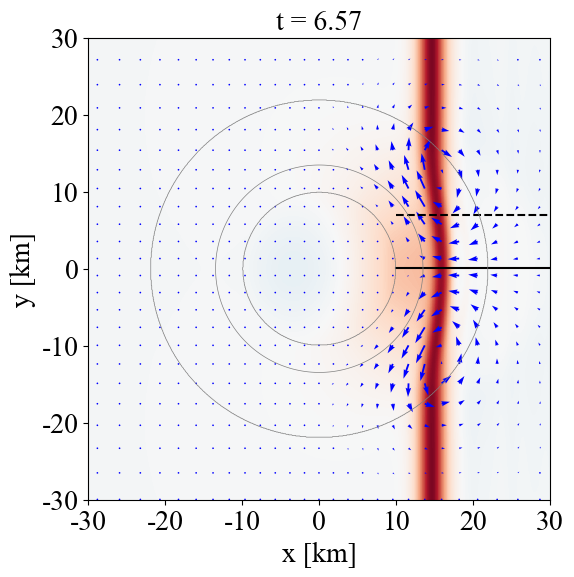

In [18]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,6))

idx_t_data = 51
ax.pcolormesh(data.x.data, data.y.data, eta_[idx_t_data,:,:].data.T, vmax=.05, vmin=-.05, cmap=cm.RdBu_r)
ax.plot(np.arange(x_c+10000,x_c+30000+1e-5, 1e3), np.ones(np.arange(x_c+10000,x_c+30000+1e-5, 1e3).shape)*data.y[int(Ny/2)+125].data, 'k--')
ax.plot(np.arange(x_c+10000,x_c+30000+1e-5, 1e3), np.ones(np.arange(x_c+10000,x_c+30000+1e-5, 1e3).shape)*data.y[int(Ny/2)].data, 'k')
Q = ax.quiver(data.x.data[::40], data.y.data[::40], (U[idx_t_data,::40,::40]*data_.depth[::40,::40].data).T, (V[idx_t_data,::40,::40]*data_.depth[::40,::40].data).T, scale=.5e2, scale_units='inches', width=4e-3, color='b')
if idx_t_data == 39: #42:
    qk = ax.quiverkey(Q, 0.1, 1.03, 1e1, r'10 m$^2$s$^{-1}$', labelpos='E', fontproperties={'size':18}, labelcolor='b')
ax.contour(data.x.data, data.y.data, data_.depth.data.T, levels = [depth_top, depth_shoal, depth_bottom], colors='.5', linewidths=.5)
ax.set_xlim([x_c-30000, x_c+30000])
ax.set_ylim([y_c-30000, y_c+30000])
ax.set_xticks(np.arange(x_c-30000,x_c+30000+1,10000))
ax.set_yticks(np.arange(y_c-30000,y_c+30000+1,10000))
ax.set_xticklabels(['-30','-20', '-10', '0', '10', '20','30'])
ax.set_yticklabels(['-30','-20', '-10', '0', '10', '20','30'])
ax.set_aspect('equal')
ax.set_xlabel('x [km]', fontsize=20)
ax.set_ylabel('y [km]', fontsize=20)
ax.set_title(f't = {np.round(t_nondim[idx_t_data],2)}', fontsize=20)
# ax.text(x_c-25000, y_c-25000, f"t = {np.round(t_nondim[idx_t_data],2)}", fontsize=20, color='k')#.026

ax.tick_params(axis='both', which='major', labelsize=20)
plt.rcParams["font.family"] = "Times New Roman"

plt.savefig(outfilepath+ f"UVeta_overhead_summer_nof.png", transparent = True, dpi=300)

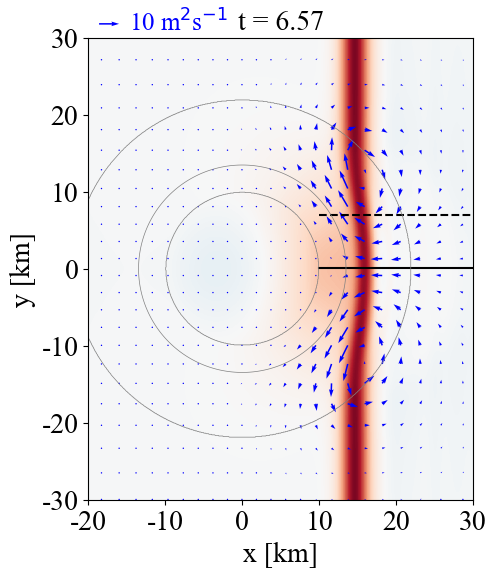

In [21]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,6))

idx_t_data = 51
ax.pcolormesh(data.x.data, data.y.data, eta_[idx_t_data,:,:].data.T, vmax=.05, vmin=-.05, cmap=cm.RdBu_r)
ax.plot(np.arange(x_c+10000,x_c+30000+1e-5, 1e3), np.ones(np.arange(x_c+10000,x_c+30000+1e-5, 1e3).shape)*data.y[int(Ny/2)+125].data, 'k--')
ax.plot(np.arange(x_c+10000,x_c+30000+1e-5, 1e3), np.ones(np.arange(x_c+10000,x_c+30000+1e-5, 1e3).shape)*data.y[int(Ny/2)].data, 'k')
Q = ax.quiver(data.x.data[::40], data.y.data[::40], (U[idx_t_data,::40,::40]*data_.depth[::40,::40].data).T, (V[idx_t_data,::40,::40]*data_.depth[::40,::40].data).T, scale=.5e2, scale_units='inches', width=4e-3, color='b')
qk = ax.quiverkey(Q, 0.08, 1.03, 1e1, r'10 m$^2$s$^{-1}$', labelpos='E', fontproperties={'size':18}, labelcolor='b')
ax.contour(data.x.data, data.y.data, data_.depth.data.T, levels = [depth_top, depth_shoal, depth_bottom], colors='.5', linewidths=.5)
ax.set_xlim([x_c-20000, x_c+30000])
ax.set_ylim([y_c-30000, y_c+30000])
ax.set_xticks(np.arange(x_c-20000,x_c+30000+1,10000))
ax.set_yticks(np.arange(y_c-30000,y_c+30000+1,10000))
ax.set_xticklabels(['-20', '-10', '0', '10', '20','30'])
ax.set_yticklabels(['-30','-20', '-10', '0', '10', '20','30'])
ax.set_aspect('equal')
ax.set_xlabel('x [km]', fontsize=20)
ax.set_ylabel('y [km]', fontsize=20)
ax.set_title(f't = {np.round(t_nondim[idx_t_data],2)}', fontsize=20)
# ax.text(x_c-25000, y_c-25000, f"t = {np.round(t_nondim[idx_t_data],2)}", fontsize=20, color='k')#.026

ax.tick_params(axis='both', which='major', labelsize=20)
plt.rcParams["font.family"] = "Times New Roman"

plt.savefig(outfilepath+ f"UVeta_overhead_summer_nof.png", transparent = True, dpi=300)

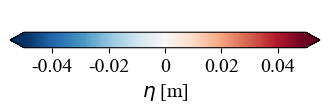

In [20]:
import matplotlib as mpl
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(4, 2))

fraction = 1  # .05

norm = mpl.colors.Normalize(vmax=.05, vmin=-.05)
cbar = ax.figure.colorbar(
            mpl.cm.ScalarMappable(norm=norm, cmap=cm.RdBu_r),
            ax=ax, pad=.15, extend='both', fraction=fraction, 
            ticks=np.arange(-.04,.04+1e-4,.02), orientation="horizontal")
cbar.ax.set_xticklabels(['-0.04','-0.02','0','0.02','0.04'])
cbar.ax.tick_params(labelsize='x-large')
cbar.set_label(label=r"$\eta$ [m]", size='x-large')
plt.rcParams["font.family"] = "Times New Roman"

ax.axis('off')
plt.savefig(outfilepath+ f"eta_colorbar_horizontal.png", transparent = True, dpi=300)